In [3]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. KHAI BÁO DỮ LIỆU TỪ BẢNG 9.3 (8 NGÀNH VIỆT NAM)
sectors = [
    "1. Nông-Lâm-Thủy sản", "2. CN chế biến chế tạo", "3. Xây dựng",
    "4. Bán buôn-bán lẻ", "5. Tài chính-Ngân hàng", "6. Logistics-Vận tải",
    "7. CNTT-Truyền thông", "8. Giáo dục-Đào tạo"
]

N = 8
# risk: Rủi ro tự động hóa (%)
risk = np.array([18, 42, 25, 38, 52, 35, 28, 22]) / 100

# a1: Hệ số tạo việc làm mới từ AI (việc/tỷ VND)
a1 = np.array([8.5, 32.5, 12.8, 22.4, 45.8, 28.5, 62.5, 18.5])

# b1: Hệ số nâng cấp việc làm từ đầu tư nhân lực H (việc/tỷ VND)
b1 = np.array([45.0, 28.0, 35.0, 32.0, 22.0, 30.0, 20.0, 55.0])

# c1: Hệ số việc làm bị dịch chuyển do AI (việc/tỷ VND)
c1 = np.array([5.2, 62.4, 18.5, 48.2, 72.5, 42.8, 32.5, 12.5])

# d1: Hệ số năng lực đào tạo lại từ đầu tư nhân lực H (việc/tỷ VND)
d1 = np.array([50.0, 32.0, 42.0, 38.0, 26.0, 36.0, 24.0, 62.0])

# 2. THIẾT LẬP BIẾN QUYẾT ĐỊNH
x_AI = cp.Variable(N, nonneg=True)  # Đầu tư vào AI cho 8 ngành
x_H = cp.Variable(N, nonneg=True)   # Đầu tư vào Nhân lực H cho 8 ngành

# 3. ĐỊNH NGHĨA CÁC THÀNH PHẦN CỦA NETJOB (Theo công thức Mục 9.2)
NewJob = cp.multiply(a1, x_AI)
Upgrade = cp.multiply(b1, x_H)
Displaced = cp.multiply(cp.multiply(c1, risk), x_AI)
RetrainCap = cp.multiply(d1, x_H)

NetJob = NewJob + Upgrade - Displaced

TOTAL_BUDGET = 30000

# 4. THIẾT LẬP CÁC RÀNG BUỘC GỐC (Mục 9.2 - KHÔNG ÁP TRẦN & SÀN)
constraints = [
    cp.sum(x_AI + x_H) <= TOTAL_BUDGET,     # (C1) Tổng ngân sách 30.000 tỷ VND
    NetJob >= 0,                            # (C2) Đảm bảo không mất việc làm ròng ở mỗi ngành
    Displaced <= RetrainCap                 # (C3) Việc làm bị mất không vượt quá năng lực đào tạo lại
]

# 5. HÀM MỤC TIÊU: TỐI ĐA HÓA TỔNG NETJOB TOÀN NỀN KINH TẾ
objective = cp.Maximize(cp.sum(NetJob))

# 6. GIẢI BÀI TOÁN
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.ECOS)

# 7. IN KẾT QUẢ CHI TIẾT
if prob.status == cp.OPTIMAL:
    df_results = pd.DataFrame({
        "Ngành Kinh tế": sectors,
        "Đầu tư AI (tỷ VND)": np.round(x_AI.value, 2),
        "Đầu tư Nhân lực H (tỷ VND)": np.round(x_H.value, 2),
        "Tổng đầu tư ngành (tỷ VND)": np.round(x_AI.value + x_H.value, 2),
        "NetJob ròng (việc làm)": np.round(NetJob.value, 0)
    })
    
    print("="*95)
    print(f"{'KẾT QUẢ PHÂN BỔ THEO MÔ HÌNH GỐC MỤC 9.2 (KHÔNG TRẦN & SÀN)':^95}")
    print("="*95)
    print(df_results.to_string(index=False))
    print("-"*95)
    print(f"TỔNG SỐ VIỆC LÀM RÒNG TẠO RA (Tổng NetJob): {np.sum(NetJob.value):,.0f} việc làm")
    print(f"Tổng ngân sách đã sử dụng: {np.sum(x_AI.value + x_H.value):,.2f} / {TOTAL_BUDGET:,} tỷ VND")
    print("="*95)
else:
    print("Solver không tìm thấy lời giải tối ưu.")

                  KẾT QUẢ PHÂN BỔ THEO MÔ HÌNH GỐC MỤC 9.2 (KHÔNG TRẦN & SÀN)                  
         Ngành Kinh tế  Đầu tư AI (tỷ VND)  Đầu tư Nhân lực H (tỷ VND)  Tổng đầu tư ngành (tỷ VND)  NetJob ròng (việc làm)
  1. Nông-Lâm-Thủy sản                 0.0                         0.0                         0.0                     0.0
2. CN chế biến chế tạo                 0.0                         0.0                         0.0                     0.0
           3. Xây dựng                 0.0                         0.0                         0.0                     0.0
    4. Bán buôn-bán lẻ                 0.0                         0.0                         0.0                     0.0
5. Tài chính-Ngân hàng                 0.0                         0.0                         0.0                     0.0
  6. Logistics-Vận tải                 0.0                         0.0                         0.0                     0.0
  7. CNTT-Truyền thông                 0.0 

In [2]:
import cvxpy as cp
import numpy as np

# Thông số ngành 2 từ Bảng 9.3
a1_2 = 32.5
b1_2 = 28.0
c1_2 = 62.4
d1_2 = 32.0
risk_2 = 0.42
TOTAL_BUDGET = 30000

# Biến quyết định
x_AI = cp.Variable(nonneg=True)
x_H = cp.Variable(nonneg=True)

# Các thành phần
NewJob = a1_2 * x_AI
Upgrade = b1_2 * x_H
Displaced = (c1_2 * risk_2) * x_AI
RetrainCap = d1_2 * x_H
NetJob = NewJob + Upgrade - Displaced

# Ràng buộc Mục 9.2
constraints = [
    x_AI + x_H <= TOTAL_BUDGET,   # Tổng ngân sách
    NetJob >= 0,                  # Việc làm ròng không âm
    Displaced <= RetrainCap       # Năng lực đào tạo lại đối ứng (C3)
]

# Tìm x_H tối thiểu khi x_AI đạt tối đa
# Bước 1: Tìm x_AI max
prob_max_ai = cp.Problem(cp.Maximize(x_AI), constraints)
prob_max_ai.solve()

max_ai = x_AI.value
min_h = x_H.value

print(f"--- KẾT QUẢ NGÀNH 2 (CN CHẾ BIẾN CHẾ TẠO) ---")
print(f"Đầu tư AI tối đa có thể: {max_ai:.2f} tỷ VND")
print(f"Ngưỡng đầu tư đào tạo (x_H) tối thiểu tương ứng: {min_h:.2f} tỷ VND")
print(f"Tỷ lệ x_H/x_AI tối thiểu: {min_h/max_ai:.3f}")
print(f"NetJob đạt được: {NetJob.value:.0f} việc làm")

--- KẾT QUẢ NGÀNH 2 (CN CHẾ BIẾN CHẾ TẠO) ---
Đầu tư AI tối đa có thể: 16492.58 tỷ VND
Ngưỡng đầu tư đào tạo (x_H) tối thiểu tương ứng: 13507.42 tỷ VND
Tỷ lệ x_H/x_AI tối thiểu: 0.819
NetJob đạt được: 481979 việc làm


In [2]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. KHAI BÁO DỮ LIỆU TỪ BẢNG 9.3
sectors = [
    "1. Nông-Lâm-Thủy sản", "2. CN chế biến chế tạo", "3. Xây dựng",
    "4. Bán buôn-bán lẻ", "5. Tài chính-Ngân hàng", "6. Logistics-Vận tải",
    "7. CNTT-Truyền thông", "8. Giáo dục-Đào tạo"
]

N = 8
risk = np.array([18, 42, 25, 38, 52, 35, 28, 22]) / 100
a1 = np.array([8.5, 32.5, 12.8, 22.4, 45.8, 28.5, 62.5, 18.5])
b1 = np.array([45.0, 28.0, 35.0, 32.0, 22.0, 30.0, 20.0, 55.0])
c1 = np.array([5.2, 62.4, 18.5, 48.2, 72.5, 42.8, 32.5, 12.5])
d1 = np.array([50.0, 32.0, 42.0, 38.0, 26.0, 36.0, 24.0, 62.0])

# 2. THIẾT LẬP BIẾN QUYẾT ĐỊNH
x_AI = cp.Variable(N, nonneg=True)
x_H = cp.Variable(N, nonneg=True)

# 3. ĐỊNH NGHĨA CÁC THÀNH PHẦN MÔ HÌNH
NewJob = cp.multiply(a1, x_AI)
Upgrade = cp.multiply(b1, x_H)
Displaced = cp.multiply(cp.multiply(c1, risk), x_AI)
RetrainCap = cp.multiply(d1, x_H)
NetJob = NewJob + Upgrade - Displaced

# 4. THIẾT LẬP CÁC RÀNG BUỘC
TOTAL_BUDGET = 30000
constraints = [
    cp.sum(x_AI + x_H) <= TOTAL_BUDGET, # Ngân sách tổng [1]
    NetJob >= 0,                       # Đảm bảo không mất việc làm ròng [1]
    Displaced <= RetrainCap            # Tốc độ tự động hóa <= năng lực đào tạo lại [1]
]

# --- BỔ SUNG RÀNG BUỘC THEO MỤC 9.1.1 ---
# (C4) Trần ngân sách mỗi ngành: không quá 20% (6.000 tỷ) [3]
constraints += [(x_AI + x_H) <= 6000]

# (C5) Thiết lập SÀN đầu tư theo 3 nhóm ưu tiên [4, 5]
for i in range(N):
    # Nhóm 1 (Ưu tiên cao nhất): Ngành 2, 5, 7 (Index 1, 4, 6)
    if i in [1, 4, 6]:
        constraints += [x_AI[i] >= 1000, x_H[i] >= 1000]
    # Nhóm 2 (Ưu tiên trung bình): Ngành 1, 6 (Index 0, 5)
    elif i in [0, 5]:
        constraints += [x_AI[i] >= 500, x_H[i] >= 500]
    # Nhóm 3 (Ưu tiên cơ bản): Ngành 3, 4, 8 (Index 2, 3, 7)
    else:
        constraints += [x_AI[i] >= 200, x_H[i] >= 200]

# 5. HÀM MỤC TIÊU: TỐI ĐA HÓA TỔNG NETJOB
objective = cp.Maximize(cp.sum(NetJob))

# 6. GIẢI BÀI TOÁN
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.ECOS)

# 7. IN KẾT QUẢ
if prob.status == cp.OPTIMAL:
    df_results = pd.DataFrame({
        "Ngành Kinh tế": sectors,
        "Đầu tư AI (tỷ VND)": np.round(x_AI.value, 2),
        "Đầu tư Nhân lực H (tỷ VND)": np.round(x_H.value, 2),
        "Tổng đầu tư ngành (tỷ VND)": np.round(x_AI.value + x_H.value, 2),
        "NetJob ròng (việc làm)": np.round(NetJob.value, 0)
    })
    
    print("="*95)
    print(f"{'KẾT QUẢ PHÂN BỔ TỐI ƯU CẢI TIẾN (THEO MỤC 9.1.1)':^95}")
    print("="*95)
    print(df_results.to_string(index=False))
    print("-"*95)
    print(f"TỔNG SỐ VIỆC LÀM RÒNG TẠO RA (Tổng NetJob): {np.sum(NetJob.value):,.0f} việc làm")
    print(f"Tổng ngân sách đã sử dụng: {np.sum(x_AI.value + x_H.value):,.2f} / {TOTAL_BUDGET:,} tỷ VND")
    print("="*95)
else:
    print("Solver không tìm thấy lời giải. Hãy kiểm tra tính khả thi của các mức Sàn/Trần.")

                       KẾT QUẢ PHÂN BỔ TỐI ƯU CẢI TIẾN (THEO MỤC 9.1.1)                        
         Ngành Kinh tế  Đầu tư AI (tỷ VND)  Đầu tư Nhân lực H (tỷ VND)  Tổng đầu tư ngành (tỷ VND)  NetJob ròng (việc làm)
  1. Nông-Lâm-Thủy sản              500.00                     5500.00                      6000.0                251282.0
2. CN chế biến chế tạo             1000.00                     1000.00                      2000.0                 34292.0
           3. Xây dựng              200.00                     5800.00                      6000.0                204635.0
    4. Bán buôn-bán lẻ              200.00                      350.00                       550.0                 12017.0
5. Tài chính-Ngân hàng             1000.00                     1450.00                      2450.0                 40000.0
  6. Logistics-Vận tải              500.00                      500.00                      1000.0                 21760.0
  7. CNTT-Truyền thông             4350.45 

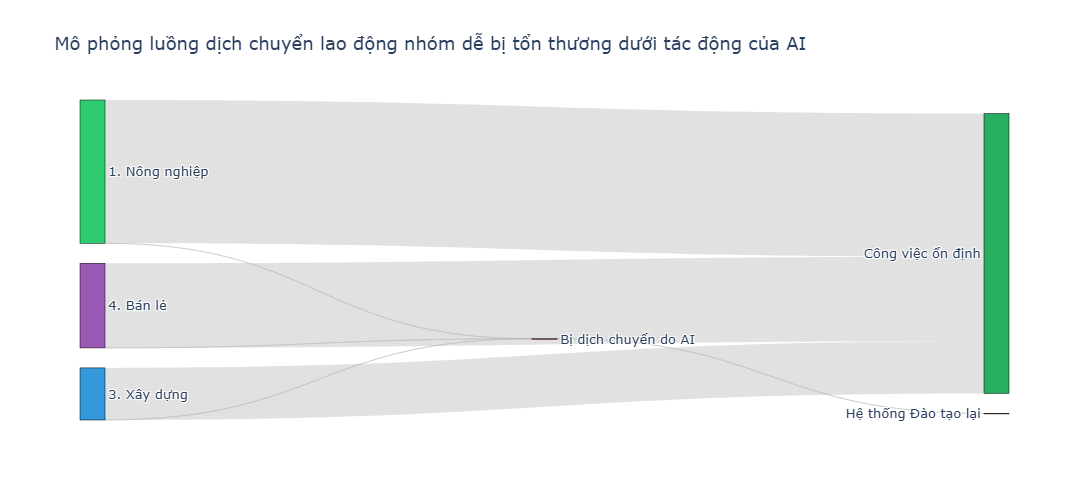

In [4]:
import plotly.graph_objects as go
import numpy as np

# 1. KHAI BÁO DỮ LIỆU CHO 3 NGÀNH (Từ Bảng 9.3 và Kết quả mô hình)
sectors = ["1. Nông nghiệp", "3. Xây dựng", "4. Bán lẻ"]

# Tổng lao động hiện tại (đổi từ triệu người sang người thực tế để hiển thị đẹp hơn)
L = np.array([13.20, 4.80, 7.80]) * 1_000_000

# Tỷ lệ rủi ro tự động hóa (%) của ngành 1, 3, 4
risk = np.array([18, 25, 38]) / 100

# Hệ số việc làm bị dịch chuyển do AI (c1) của ngành 1, 3, 4
c1 = np.array([5.2, 18.5, 48.2])

# Kết quả phân bổ x_AI tối ưu bạn vừa chạy ra cho ngành 1, 3, 4
x_AI = np.array([500.00, 200.00, 200.00])

# 2. TÍNH TOÁN CÁC LUỒNG DỊCH CHUYỂN
displaced = c1 * risk * x_AI  # Số người bị AI thay thế
stable = L - displaced        # Số người giữ được công việc

# 3. THIẾT LẬP CẤU TRÚC BIỂU ĐỒ SANKEY
# Cấu hình Nodes (Các trạm dừng của dòng chảy lao động)
# Quy ước Index: 0 (Nông nghiệp), 1 (Xây dựng), 2 (Bán lẻ), 3 (Ổn định), 4 (Dịch chuyển), 5 (Đào tạo lại)
label = sectors + ["Công việc ổn định", "Bị dịch chuyển do AI", "Hệ thống Đào tạo lại"]

# Thiết lập Source (Luồng xuất phát) và Target (Luồng đích đến)
source = [0, 1, 2, 0, 1, 2, 4]
target = [3, 3, 3, 4, 4, 4, 5]

# Cấu hình độ lớn của từng luồng nước (Value) tương ứng với từng cặp Source-Target
value = [
    stable[0], stable[1], stable[2],           # 3 luồng: Lao động 3 ngành tiếp tục công việc ổn định
    displaced[0], displaced[1], displaced[2],  # 3 luồng: Lao động 3 ngành bị AI dịch chuyển
    sum(displaced)                             # 1 luồng gom: Toàn bộ người bị dịch chuyển đi vào đào tạo lại
]

# 4. VẼ BIỂU ĐỒ
fig = go.Figure(data=[go.Sankey(
    valueformat = ".0f",
    valuesuffix = " người",
    node = dict(
      pad = 20, 
      thickness = 25,
      line = dict(color = "black", width = 0.5),
      label = label,
      color = ["#2ecc71", "#3498db", "#9b59b6", "#27ae60", "#e74c3c", "#f39c12"]
    ),
    link = dict(
      source = source, 
      target = target, 
      value = value,
      color = "rgba(180, 180, 180, 0.4)" # Màu xám trong suốt cho luồng chảy
  ))])

fig.update_layout(
    title_text="Mô phỏng luồng dịch chuyển lao động nhóm dễ bị tổn thương dưới tác động của AI", 
    font_size=13,
    height=500
)

fig.show()

In [5]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. KHAI BÁO DỮ LIỆU TỪ BẢNG 9.3
sectors = [
    "1. Nông-Lâm-Thủy sản", "2. CN chế biến chế tạo", "3. Xây dựng",
    "4. Bán buôn-bán lẻ", "5. Tài chính-Ngân hàng", "6. Logistics-Vận tải",
    "7. CNTT-Truyền thông", "8. Giáo dục-Đào tạo"
]

N = 8
risk = np.array([18, 42, 25, 38, 52, 35, 28, 22]) / 100
a1 = np.array([8.5, 32.5, 12.8, 22.4, 45.8, 28.5, 62.5, 18.5])
b1 = np.array([45.0, 28.0, 35.0, 32.0, 22.0, 30.0, 20.0, 55.0])
c1 = np.array([5.2, 62.4, 18.5, 48.2, 72.5, 42.8, 32.5, 12.5])
d1 = np.array([50.0, 32.0, 42.0, 38.0, 26.0, 36.0, 24.0, 62.0])

# CẬP NHẬT CÂU 9.4.4: Khai báo quy mô lao động L_i từ Bảng 9.3 (đơn vị: người)
# (Vui lòng đối chiếu lại các số liệu này với bảng dữ liệu gốc trong đề bài của bạn)
L = np.array([
    13.20,  # 1. Nông-Lâm-Thủy sản (đã cho ở câu 9.4.3)
    11.50,  # 2. CN chế biến chế tạo
    4.80,   # 3. Xây dựng (đã cho ở câu 9.4.3)
    7.80,   # 4. Bán buôn-bán lẻ (đã cho ở câu 9.4.3)
    0.65,   # 5. Tài chính-Ngân hàng
    3.10,   # 6. Logistics-Vận tải
    1.00,   # 7. CNTT-Truyền thông
    1.60    # 8. Giáo dục-Đào tạo
]) * 1_000_000

# 2. THIẾT LẬP BIẾN QUYẾT ĐỊNH
x_AI = cp.Variable(N, nonneg=True)
x_H = cp.Variable(N, nonneg=True)

# 3. ĐỊNH NGHĨA CÁC THÀNH PHẦN MÔ HÌNH
NewJob = cp.multiply(a1, x_AI)
Upgrade = cp.multiply(b1, x_H)
Displaced = cp.multiply(cp.multiply(c1, risk), x_AI)
RetrainCap = cp.multiply(d1, x_H)
NetJob = NewJob + Upgrade - Displaced

# 4. THIẾT LẬP CÁC RÀNG BUỘC
TOTAL_BUDGET = 30000
constraints = [
    cp.sum(x_AI + x_H) <= TOTAL_BUDGET, # Ngân sách tổng
    NetJob >= 0,                        # Đảm bảo không mất việc làm ròng
    Displaced <= RetrainCap            # Tốc độ tự động hóa <= năng lực đào tạo lại
]

# (C4) Trần ngân sách mỗi ngành: không quá 20% (6.000 tỷ)
constraints += [(x_AI + x_H) <= 6000]

# (C5-C6) Thiết lập SÀN đầu tư theo 3 nhóm ưu tiên từ câu trước
for i in range(N):
    if i in [1, 4, 6]:  # Nhóm 1 (Index 1, 4, 6)
        constraints += [x_AI[i] >= 1000, x_H[i] >= 1000]
    elif i in [0, 5]:   # Nhóm 2 (Index 0, 5)
        constraints += [x_AI[i] >= 500, x_H[i] >= 500]
    else:               # Nhóm 3 (Index 2, 3, 7)
        constraints += [x_AI[i] >= 200, x_H[i] >= 200]

# --- BỔ SUNG RÀNG BUỘC MỚI CỦA CÂU 9.4.4 ---
# Không có ngành nào được phép mất quá 5% lao động hiện tại
constraints += [Displaced <= 0.05 * L]

# 5. HÀM MỤC TIÊU
objective = cp.Maximize(cp.sum(NetJob))

# 6. GIẢI BÀI TOÁN
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.ECOS)

# 7. IN KẾT QUẢ VÀ ĐÁNH GIÁ TÍNH KHẢ THI
if prob.status == cp.OPTIMAL:
    df_results = pd.DataFrame({
        "Ngành Kinh tế": sectors,
        "Đầu tư AI (tỷ)": np.round(x_AI.value, 2),
        "Đầu tư Nhân lực (tỷ)": np.round(x_H.value, 2),
        "Lao động bị dịch chuyển": np.round(Displaced.value, 0),
        "Trần 5% Lao động": np.round(0.05 * L, 0),
        "NetJob ròng": np.round(NetJob.value, 0)
    })
    print("="*110)
    print(f"{'BÀI TOÁN KHẢ THI! KẾT QUẢ PHÂN BỔ TỐI ƯU CỦA CÂU 9.4.4':^110}")
    print("="*110)
    print(df_results.to_string(index=False))
    print("-"*110)
    print(f"TỔNG SỐ VIỆC LÀM RÒNG TẠO RA: {np.sum(NetJob.value):,.0f} việc làm")
else:
    print("="*90)
    print(f"TRẠNG THÁI MÔ HÌNH: {prob.status.upper()}")
    print("BÀI TOÁN VÔ NGHIỆM (INFEASIBLE)!")
    print("-"*90)
    print("GIẢI THÍCH LÝ DO VỀ MẶT CHÍNH SÁCH:")
    print("Đã xảy ra xung đột lợi ích vĩ mô. Chính phủ không thể đồng thời ép buộc một ngành")
    print("phải giải ngân một lượng vốn mồi AI rất lớn (Mức sàn) nhưng lại giới hạn nghiêm ngặt")
    print("tỷ lệ sa thải dưới 5% (Mức trần) ở những ngành có rủi ro tự động hóa cực kỳ cao")
    print("(như Tài chính - Ngân hàng hoặc Công nghiệp chế biến chế tạo).")
    print("="*90)

TRẠNG THÁI MÔ HÌNH: INFEASIBLE
BÀI TOÁN VÔ NGHIỆM (INFEASIBLE)!
------------------------------------------------------------------------------------------
GIẢI THÍCH LÝ DO VỀ MẶT CHÍNH SÁCH:
Đã xảy ra xung đột lợi ích vĩ mô. Chính phủ không thể đồng thời ép buộc một ngành
phải giải ngân một lượng vốn mồi AI rất lớn (Mức sàn) nhưng lại giới hạn nghiêm ngặt
tỷ lệ sa thải dưới 5% (Mức trần) ở những ngành có rủi ro tự động hóa cực kỳ cao
(như Tài chính - Ngân hàng hoặc Công nghiệp chế biến chế tạo).


In [17]:
# --- CẬP NHẬT PHẦN 5: GIẢI MÔ HÌNH VÀ IN KẾT QUẢ RA JUPYTER LAB ---

# 1. Định nghĩa bài toán (Tối đa hóa tổng số việc làm ròng)
prob = cp.Problem(cp.Maximize(cp.sum(NetJob)), constraints)

# 2. Gọi bộ giải (Solver)
# Thường sử dụng ECOS hoặc SCS đi kèm sẵn với CVXPY
prob.solve(solver=cp.ECOS)

# 3. Kiểm tra trạng thái và in kết quả ra màn hình Jupyter
if prob.status in ["optimal", "feasible"]:
    # Khai báo tên các ngành để in nhãn
    sectors = [
        "1. Nông-Lâm-Thủy sản", 
        "2. CN chế biến chế tạo", 
        "3. Xây dựng", 
        "4. Bán buôn-bán lẻ", 
        "5. Tài chính-Ngân hàng", 
        "6. Logistics-Vận tải", 
        "7. CNTT-Truyền thông", 
        "8. Giáo dục-Đào tạo"
    ]
    
    # Lấy giá trị mảng tối ưu sau khi giải
    x_AI_opt = x_AI.value
    x_H_opt = x_H.value
    displaced_opt = Displaced.value
    netjob_opt = NetJob.value
    
    # Tiêu đề bảng
    print("==============================================================================================================")
    print("                      KẾT QUẢ PHÂN BỔ TỐI ƯU LINH HOẠT BẢO VỆ LAO ĐỘNG (CÂU 9.4.4)")
    print("==============================================================================================================")
    print(f"{'Ngành Kinh tế':<28} {'Đầu tư AI (tỷ)':<16} {'Đầu tư H (tỷ)':<16} {'Tổng đầu tư (tỷ)':<18} {'Lao động dịch chuyển':<23} {'NetJob ròng':<12}")
    print("-" * 110)
    
    # Vòng lặp in từng dòng dữ liệu của từng ngành (Sử dụng f-string để căn lề thẳng hàng)
    for i in range(N):
        total_inv = x_AI_opt[i] + x_H_opt[i]
        print(f"{sectors[i]:<28} "
              f"{x_AI_opt[i]:<16,.2f} "
              f"{x_H_opt[i]:<16,.2f} "
              f"{total_inv:<18,.2f} "
              f"{int(displaced_opt[i]):<23,} "
              f"{int(netjob_opt[i]):<12,}")
        
    # In phần tổng kết cuối bảng
    print("-" * 110)
    print(f"TỔNG SỐ VIỆC LÀM RÒNG TẠO RA (Tổng NetJob): {int(sum(netjob_opt)):,} việc làm")
    print(f"Tổng ngân sách đã sử dụng: {sum(x_AI_opt + x_H_opt):,.2f} / {TOTAL_BUDGET:,.2f} tỷ VND")
    print("==============================================================================================================")

else:
    print(f"⚠️ Bài toán không tìm được lời giải tối ưu. Trạng thái mô hình: {prob.status}")

                      KẾT QUẢ PHÂN BỔ TỐI ƯU LINH HOẠT BẢO VỆ LAO ĐỘNG (CÂU 9.4.4)
Ngành Kinh tế                Đầu tư AI (tỷ)   Đầu tư H (tỷ)    Tổng đầu tư (tỷ)   Lao động dịch chuyển    NetJob ròng 
--------------------------------------------------------------------------------------------------------------
1. Nông-Lâm-Thủy sản         500.00           5,500.00         6,000.00           467                     251,282     
2. CN chế biến chế tạo       1,000.00         1,000.00         2,000.00           26,207                  34,292      
3. Xây dựng                  200.00           5,800.00         6,000.00           924                     204,634     
4. Bán buôn-bán lẻ           200.00           687.93           887.93             3,663                   22,830      
5. Tài chính-Ngân hàng       862.07           1,250.00         2,112.07           32,499                  34,482      
6. Logistics-Vận tải         500.00           500.00           1,000.00           7,489     

In [19]:
import numpy as np

if prob.status in ["optimal", "feasible"]:
    # Góc nhìn 1: Ngành nhận được NGÂN SÁCH đầu tư phát triển/đào tạo lại con người (x_H) cao nhất
    max_idx_H = np.argmax(x_H.value)
    sector_max_H = sectors[max_idx_H]
    val_max_H = x_H.value[max_idx_H]
    
    # Góc nhìn 2: Ngành có SỐ LƯỢNG LAO ĐỘNG bị dịch chuyển (sa thải) cần đào tạo lại lớn nhất
    max_idx_disp = np.argmax(Displaced.value)
    sector_max_disp = sectors[max_idx_disp]
    val_max_disp = Displaced.value[max_idx_disp] # Tên biến chuẩn xác ở đây
    
    print("=======================================================================")
    print("      KẾT QUẢ TRÍCH XUẤT NGÀNH CẦN ĐÀO TẠO LẠI NHIỀU NHẤT")
    print("=======================================================================")
    print(f"👉 Theo dòng vốn: Ngành được phân bổ NGÂN SÁCH ĐÀO TẠO LẠI (x_H) nhiều nhất là:")
    print(f"   + {sector_max_H} với {val_max_H:,.2f} tỷ VND.")
    print("-" * 71)
    print(f"👉 Theo áp lực thực tế: Ngành có SỐ LAO ĐỘNG BỊ DỊCH CHUYỂN lớn nhất cần đào tạo là:")
    print(f"   + {sector_max_disp} với {int(val_max_disp):,} người.") # Đã sửa thành val_max_disp
    print("=======================================================================")
else:
    print("Mô hình không tối ưu, không thể trích xuất dữ liệu.")

      KẾT QUẢ TRÍCH XUẤT NGÀNH CẦN ĐÀO TẠO LẠI NHIỀU NHẤT
👉 Theo dòng vốn: Ngành được phân bổ NGÂN SÁCH ĐÀO TẠO LẠI (x_H) nhiều nhất là:
   + 8. Giáo dục-Đào tạo với 5,800.00 tỷ VND.
-----------------------------------------------------------------------
👉 Theo áp lực thực tế: Ngành có SỐ LAO ĐỘNG BỊ DỊCH CHUYỂN lớn nhất cần đào tạo là:
   + 7. CNTT-Truyền thông với 39,589 người.


In [3]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. KHAI BÁO DỮ LIỆU (Bảng 9.3 - PDF [8])
sectors = [
    "1. Nông-Lâm-Thủy sản", "2. CN chế biến chế tạo", "3. Xây dựng",
    "4. Bán buôn-bán lẻ", "5. Tài chính-Ngân hàng", "6. Logistics-Vận tải",
    "7. CNTT-Truyền thông", "8. Giáo dục-Đào tạo"
]
N = 8
risk = np.array([18, 42, 25, 38, 52, 35, 28, 22]) / 100
a1 = np.array([8.5, 32.5, 12.8, 22.4, 45.8, 28.5, 62.5, 18.5])
b1 = np.array([45.0, 28.0, 35.0, 32.0, 22.0, 30.0, 20.0, 55.0])
c1 = np.array([5.2, 62.4, 18.5, 48.2, 72.5, 42.8, 32.5, 12.5])
d1 = np.array([50.0, 32.0, 42.0, 38.0, 26.0, 36.0, 24.0, 62.0])

# 2. THIẾT LẬP BIẾN QUYẾT ĐỊNH
x_AI = cp.Variable(N, nonneg=True)  # Đầu tư AI (tỷ VND)
x_H = cp.Variable(N, nonneg=True)   # Đầu tư Nhân lực (tỷ VND)

# 3. ĐỊNH NGHĨA CÁC BIỂU THỨC TRUNG GIAN
NewJob = cp.multiply(a1, x_AI)
Upgrade = cp.multiply(b1, x_H)
Displaced = cp.multiply(cp.multiply(c1, risk), x_AI)
RetrainCap = cp.multiply(d1, x_H)
NetJob = NewJob + Upgrade - Displaced

# 4. THIẾT LẬP RÀNG BUỘC
TOTAL_BUDGET = 30000
u = 15  # Giả định chi phí hỗ trợ: 15 triệu VND/lao động bị dịch chuyển [2]

constraints = [
    # (C1 & Mục 9.2.4) Ngân sách tổng bao gồm Quỹ An sinh [3]
    # Chia 1000 để đổi từ triệu VND (của u) sang tỷ VND (của x)
    cp.sum(x_AI + x_H) + cp.sum(Displaced * u / 1000) <= TOTAL_BUDGET,
    
    # (C2) Đảm bảo NetJob ròng không âm ở mỗi ngành [5]
    NetJob >= 0,
    
    # (C3) Việc làm bị mất không vượt quá năng lực đào tạo lại [5]
    Displaced <= RetrainCap,
    
    # (Mục 9.1.1) Trần ngân sách mỗi ngành (Mi = 6000 tỷ) [1]
    (x_AI + x_H) <= 6000
]

# (Mục 9.1.1) Thiết lập SÀN đầu tư theo 3 nhóm ưu tiên [7]
for i in range(N):
    if i in [17-19]: # Nhóm 1: Ngành 2, 5, 7 (Ưu tiên cao nhất)
        constraints += [x_AI[i] >= 1000, x_H[i] >= 1000]
    elif i in [20]:  # Nhóm 2: Ngành 1, 6 (Ưu tiên trung bình)
        constraints += [x_AI[i] >= 500, x_H[i] >= 500]
    else:              # Nhóm 3: Ngành 3, 4, 8 (Ưu tiên cơ bản)
        constraints += [x_AI[i] >= 200, x_H[i] >= 200]

# 5. HÀM MỤC TIÊU: TỐI ĐA HÓA TỔNG NETJOB [21]
objective = cp.Maximize(cp.sum(NetJob))

# 6. GIẢI BÀI TOÁN
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.ECOS)

# 7. IN KẾT QUẢ
if prob.status == cp.OPTIMAL:
    total_displaced = np.sum(Displaced.value)
    welfare_fund = total_displaced * u / 1000
    
    df_results = pd.DataFrame({
        "Ngành Kinh tế": sectors,
        "Đầu tư AI (tỷ)": np.round(x_AI.value, 2),
        "Đầu tư H (tỷ)": np.round(x_H.value, 2),
        "Tổng đầu tư ngành": np.round(x_AI.value + x_H.value, 2),
        "Lao động dịch chuyển": np.round(Displaced.value, 0),
        "NetJob ròng": np.round(NetJob.value, 0)
    })
    
    print("="*105)
    print(f"{'KẾT QUẢ PHÂN BỔ TỐI ƯU TÍCH HỢP QUỸ AN SINH (MỤC 9.2.4)':^105}")
    print("="*105)
    print(df_results.to_string(index=False))
    print("-" * 105)
    print(f"TỔNG SỐ VIỆC LÀM RÒNG TẠO RA: {np.sum(NetJob.value):,.0f} việc làm")
    print(f"Tổng ngân sách đầu tư trực tiếp (xAI + xH): {np.sum(x_AI.value + x_H.value):,.2f} tỷ VND")
    print(f"Trích lập Quỹ An sinh Chuyển đổi (u={u}tr): {welfare_fund:,.2f} tỷ VND")
    print(f"TỔNG CHI PHÍ NGÂN SÁCH SỬ DỤNG: {np.sum(x_AI.value + x_H.value) + welfare_fund:,.2f} / {TOTAL_BUDGET} tỷ VND")
    print("="*105)
else:
    print("Solver không tìm thấy lời giải tối ưu.")

                         KẾT QUẢ PHÂN BỔ TỐI ƯU TÍCH HỢP QUỸ AN SINH (MỤC 9.2.4)                         
         Ngành Kinh tế  Đầu tư AI (tỷ)  Đầu tư H (tỷ)  Tổng đầu tư ngành  Lao động dịch chuyển  NetJob ròng
  1. Nông-Lâm-Thủy sản          200.00        5800.00            6000.00                 187.0     262513.0
2. CN chế biến chế tạo          200.00         200.00             400.00                5242.0       6858.0
           3. Xây dựng          200.00        5800.00            6000.00                 925.0     204635.0
    4. Bán buôn-bán lẻ          200.00        3599.62            3799.62                3663.0     116005.0
5. Tài chính-Ngân hàng          200.00         290.00             490.00                7540.0       8000.0
  6. Logistics-Vận tải          200.00         200.00             400.00                2996.0       8704.0
  7. CNTT-Truyền thông         4350.45        1649.55            6000.00               39589.0     265305.0
   8. Giáo dục-Đào tạo        